In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MCF7 Smart Data


In [ ]:
%%sql


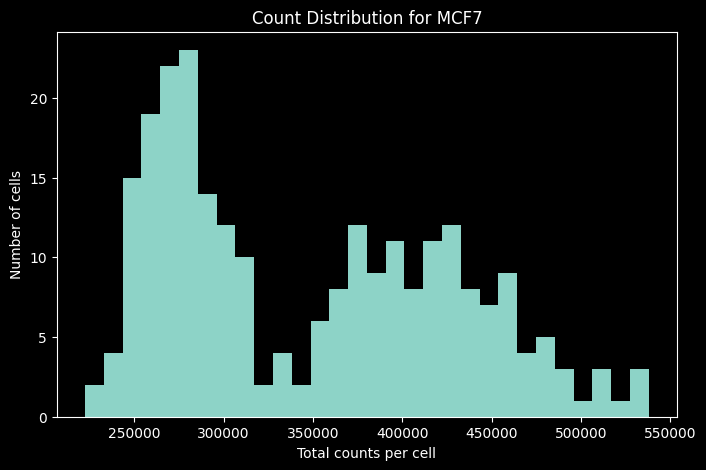

count       250.000000
mean     347700.148000
std       80179.689956
min      222421.000000
25%      275370.500000
50%      330296.000000
75%      416534.500000
max      537979.000000
dtype: float64


In [2]:
counts_MCF7 = pd.read_csv("MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt", sep=r"\s+", index_col=0)
metadata_MCF7 = pd.read_csv("MCF7_SmartS_MetaData.tsv", sep="\t")

library_size = counts_MCF7.sum(axis=0)
plt.figure(figsize=(8,5))
plt.hist(library_size, bins=30)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Count Distribution for MCF7")
plt.show()
print(library_size.describe())

In [8]:
counts_MCF7.columns = counts_MCF7.columns.str.extract(r'(S\d+)', expand=False)

meta = metadata_MCF7[["Cell name", "Condition"]]
norm_cells = meta[meta["Condition"] == "Norm"]["Cell name"]
hypo_cells = meta[meta["Condition"] == "Hypo"]["Cell name"]
norm_cells = [c for c in norm_cells if c in counts_MCF7.columns]
hypo_cells = [c for c in hypo_cells if c in counts_MCF7.columns]

MCF7_normoxia = counts_MCF7[norm_cells]
MCF7_hypoxia = counts_MCF7[hypo_cells]


#SEE DIFERENCE BETWEEN HYPOX AND NORMOX
mean_norm = MCF7_normoxia.mean(axis=1)
mean_hypo = MCF7_hypoxia.mean(axis=1)
diff = mean_hypo - mean_norm
diff_abs = diff.abs().sort_values(ascending=False)
logFC = np.log2((mean_hypo + 1) / (mean_norm + 1))
logFC_sorted = logFC.sort_values(ascending=False)

results = pd.DataFrame({
    "mean_norm": mean_norm,
    "mean_hypo": mean_hypo,
    "difference": diff,
    "logFC": logFC
})
results_sorted = results.sort_values("logFC", ascending=False)

MCF7_normoxia
MCF7_hypoxia

,S79,S81,S130,S131,S128,S129,S178,S179,S180,S175,...,S335,S336,S331,S332,S333,S382,S383,S379,S380,S381
CYP1B1,5817,3841,9263,21543,1338,10043,3435,8579,3111,12164,...,13805,27531,10805,2165,17970,7890,4512,34565,20024,5953
CYP1B1-AS1,2669,1565,3866,9113,554,4191,1624,3974,1374,5871,...,5937,11426,4712,941,7653,3647,2035,13717,7835,2367
CYP1A1,0,79,238,443,14,50,170,4312,0,1,...,2658,58717,1844,4171,1,86,1654,11274,563,522
NDRG1,654,1263,2634,540,634,1084,460,1292,1339,869,...,943,925,1206,488,781,481,1052,1263,925,1572
DDIT4,2484,2596,1323,2044,3513,2438,1668,4602,2456,10157,...,3768,4921,4712,4196,4098,3692,2410,4256,12733,2275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRIK5,0,0,0,0,0,6,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
SLC25A27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DENND5A,60,107,74,127,14,0,18,31,0,18,...,78,15,54,0,219,179,97,140,7,37
CDK5R1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


NDRG1     0.083439
HK2       0.076227
CYP1A1    0.070522
ASF1B     0.068645
TK1       0.065873
MYBL2     0.065826
PFKFB4    0.064534
ZWINT     0.063591
DDIT4     0.061604
RECQL4    0.061296
Name: PC1, dtype: float64
AREG          0.120353
ALCAM         0.101603
ELAPOR1       0.101553
CCN5          0.093233
PKP3          0.088764
MDK           0.084379
ST6GALNAC2    0.081893
TFF3          0.080473
SPOCK1        0.080240
TRIP6         0.080095
Name: PC2, dtype: float64


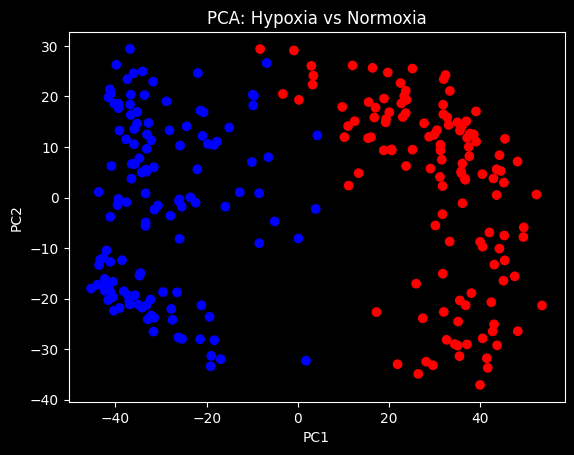

In [9]:
#PCA
from sklearn.decomposition import PCA

X = counts_MCF7.T
X_log = np.log1p(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_log)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

top_PC1 = loadings["PC1"].abs().sort_values(ascending=False)
print(top_PC1.head(10))
top_PC2 = loadings["PC2"].abs().sort_values(ascending=False)
print(top_PC2.head(10))
loadings["PC1"].sort_values(ascending=False).head(10)   # positive side
loadings["PC1"].sort_values().head(10)                  # negative side

# colors
colors = ["red" if c in hypo_cells else "blue" for c in X.index]

plt.scatter(X_pca[:,0], X_pca[:,1], c=colors)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Hypoxia vs Normoxia")
plt.show()

Now we move on to making the models for classifying Hypoxic vs Normoxic cells in the Smart MCF7

In [10]:
X = counts_MCF7.T
y = pd.Series(
    ["Hypo" if c in hypo_cells else "Norm" for c in X.index],
    index=X.index
)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(name, best_model, X_test, y_test):
    y_pred = best_model.predict(X_test)

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    print("Best parameters:", best_model)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return y_pred


Logistic regression

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("\nBest Logistic Regression parameters:", grid_lr.best_params_)
print("Best Logistic Regression CV score:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
evaluate_model("LOGISTIC REGRESSION", best_lr, X_test, y_test)

# coefficients
lr_model = best_lr.named_steps["model"]
coef = pd.Series(lr_model.coef_[0], index=X.columns)

results_lr = pd.DataFrame({
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

print("Intercept:", lr_model.intercept_)
print("Top positive genes:")
print(results_lr.head(10))
print("Top negative genes:")
print(results_lr.tail(10))



Best Logistic Regression parameters: {'model__C': 0.001}
Best Logistic Regression CV score: 1.0

LOGISTIC REGRESSION
Best parameters: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.001, max_iter=1000, random_state=42))])
Test Accuracy: 1.0
              precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00        25
        Norm       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Confusion Matrix:
[[25  0]
 [ 0 25]]
Intercept: [-0.01629782]
Top positive genes:
          coefficient
MT-CYB       0.012789
MT-CO3       0.012340
MTATP6P1     0.012226
MT-ATP6      0.012211
MT-CO2       0.011874
MT-ATP8      0.011435
MT-CO1       0.010863
IFITM2       0.010516
FDPS         0.010492
PSME2        0.010442
Top negative genes:
         coefficient
BN

Linear SVM

In [12]:
from sklearn.svm import SVC

svm_linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear"))
])

param_grid_svm_linear = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_svm_linear = GridSearchCV(
    estimator=svm_linear_pipeline,
    param_grid=param_grid_svm_linear,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm_linear.fit(X_train, y_train)

print("\nBest Linear SVM parameters:", grid_svm_linear.best_params_)
print("Best Linear SVM CV score:", grid_svm_linear.best_score_)

best_svm_linear = grid_svm_linear.best_estimator_
evaluate_model("LINEAR SVM", best_svm_linear, X_test, y_test)


Best Linear SVM parameters: {'model__C': 0.001}
Best Linear SVM CV score: 1.0

LINEAR SVM
Best parameters: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(C=0.001, kernel='linear'))])
Test Accuracy: 1.0
              precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00        25
        Norm       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Confusion Matrix:
[[25  0]
 [ 0 25]]


array(['Norm', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Norm', 'Norm', 'Hypo',
       'Norm', 'Hypo', 'Hypo', 'Hypo', 'Norm', 'Hypo', 'Norm', 'Hypo',
       'Hypo', 'Norm', 'Hypo', 'Hypo', 'Norm', 'Norm', 'Norm', 'Hypo',
       'Hypo', 'Norm', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Norm', 'Norm',
       'Norm', 'Norm', 'Norm', 'Norm', 'Norm', 'Norm', 'Norm', 'Hypo',
       'Norm', 'Norm', 'Norm', 'Hypo', 'Norm', 'Hypo', 'Hypo', 'Norm',
       'Hypo', 'Hypo'], dtype=object)

RBF Kernel SVM

In [13]:
svm_rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

param_grid_svm_rbf = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": [0.001, 0.01, 0.1, 1]
}

grid_svm_rbf = GridSearchCV(
    estimator=svm_rbf_pipeline,
    param_grid=param_grid_svm_rbf,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm_rbf.fit(X_train, y_train)

print("\nBest RBF SVM parameters:", grid_svm_rbf.best_params_)
print("Best RBF SVM CV score:", grid_svm_rbf.best_score_)

best_svm_rbf = grid_svm_rbf.best_estimator_
evaluate_model("RBF SVM", best_svm_rbf, X_test, y_test)


Best RBF SVM parameters: {'model__C': 10, 'model__gamma': 0.001}
Best RBF SVM CV score: 0.6143474582032935

RBF SVM
Best parameters: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(C=10, gamma=0.001))])
Test Accuracy: 0.74
              precision    recall  f1-score   support

        Hypo       0.66      1.00      0.79        25
        Norm       1.00      0.48      0.65        25

    accuracy                           0.74        50
   macro avg       0.83      0.74      0.72        50
weighted avg       0.83      0.74      0.72        50

Confusion Matrix:
[[25  0]
 [13 12]]


array(['Norm', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo',
       'Norm', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo',
       'Hypo', 'Norm', 'Hypo', 'Hypo', 'Norm', 'Hypo', 'Hypo', 'Hypo',
       'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Hypo', 'Norm',
       'Norm', 'Hypo', 'Norm', 'Norm', 'Hypo', 'Hypo', 'Norm', 'Hypo',
       'Hypo', 'Norm', 'Norm', 'Hypo', 'Norm', 'Hypo', 'Hypo', 'Hypo',
       'Hypo', 'Hypo'], dtype=object)

Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    "n_estimators": [100, 200, 500],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest Random Forest parameters:", grid_rf.best_params_)
print("Best Random Forest CV score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
evaluate_model("RANDOM FOREST", best_rf, X_test, y_test)

print("OOB Score:", best_rf.oob_score_)

rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
rf_results = pd.DataFrame({
    "importance": rf_importances
}).sort_values("importance", ascending=False)

print("Top important genes (Random Forest):")
print(rf_results.head(10))



Best Random Forest parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best Random Forest CV score: 0.9949968730456537

RANDOM FOREST
Best parameters: RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=42)
Test Accuracy: 1.0
              precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00        25
        Norm       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Confusion Matrix:
[[25  0]
 [ 0 25]]
OOB Score: 0.995
Top important genes (Random Forest):
              importance
MT-CO3          0.041579
GPI             0.038714
FAM162A         0.036015
MT-ATP6         0.027458
BNIP3           0.026239
DSP             0.025890
ERO1A           0.025420
SLC9A3R1-AS1    0.024857
CYP1B1          0.019043
ENO2            0.017143


Ada Boost

In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

param_grid_ada = {
    "estimator__max_depth": [1, 2, 3],
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid_ada,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print("\nBest AdaBoost parameters:", grid_ada.best_params_)
print("Best AdaBoost CV score:", grid_ada.best_score_)

best_ada = grid_ada.best_estimator_
evaluate_model("ADABOOST", best_ada, X_test, y_test)

ada_importances = pd.Series(best_ada.feature_importances_, index=X.columns)
ada_results = pd.DataFrame({
    "importance": ada_importances
}).sort_values("importance", ascending=False)

print("Top important genes (AdaBoost):")
print(ada_results.head(10))



Best AdaBoost parameters: {'estimator__max_depth': 1, 'learning_rate': 0.5, 'n_estimators': 200}
Best AdaBoost CV score: 0.9949968730456537

ADABOOST
Best parameters: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=200, random_state=42)
Test Accuracy: 1.0
              precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00        25
        Norm       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Confusion Matrix:
[[25  0]
 [ 0 25]]
Top important genes (AdaBoost):
         importance
NDRG1      0.241785
MT-CO3     0.108221
GAPDH      0.062096
IFITM2     0.059876
TST        0.033781
CYP1B1     0.031506
PFKP       0.031197
MVD        0.029707
SNRNP25    0.025320
TFRC     

XGBoost

In [20]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost expects numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_grid_xgb = {
    "n_estimators": [50,100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}


random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter= 20,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

random_xgb.fit(X_train, y_train_enc)

print("\nBest XGBoost parameters:", random_xgb.best_params_)
print("Best XGBoost CV score:", random_xgb.best_score_)

best_xgb = random_xgb.best_estimator_

# predictions
y_pred_xgb_enc = best_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print(f"\n{'='*50}")
print("XGBOOST")
print(f"{'='*50}")
print("Best estimator:", best_xgb)
print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

xgb_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
xgb_results = pd.DataFrame({
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

print("Top important genes (XGBoost):")
print(xgb_results.head(10))


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/martimmaia/PycharmProjects/PythonProject/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/martimmaia/PycharmProjects/PythonProject/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptex

Final Comparison Table for MCF7 classification models

In [18]:
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "RBF SVM",
        "Random Forest",
        "AdaBoost",
        "XGBoost"
    ],
    "Best CV F1_macro": [
        grid_lr.best_score_,
        grid_svm_linear.best_score_,
        grid_svm_rbf.best_score_,
        grid_rf.best_score_,
        grid_ada.best_score_,
        random_xgb.best_score_
    ]
})

comparison_results = comparison_results.sort_values("Best CV F1_macro", ascending=False)

print(f"\n{'='*50}")
print("MODEL COMPARISON")
print(f"{'='*50}")
print(comparison_results)

NameError: name 'random_xgb' is not defined